In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/apoorvaappz/global-super-store-dataset/Global_Superstore2.xlsx
/kaggle/input/datasets/apoorvaappz/global-super-store-dataset/Global_Superstore2.csv


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import shutil

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

In [4]:
os.makedirs("/kaggle/working/Visual_Reports", exist_ok=True)

def save_plot(filename):
    plt.savefig(
        f"/kaggle/working/Visual_Reports/{filename}",
        bbox_inches='tight'
    )
    plt.show()

In [6]:
df = pd.read_csv(
    "/kaggle/input/datasets/apoorvaappz/global-super-store-dataset/Global_Superstore2.csv",
    encoding="latin1"
)

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,32298,CA-2012-124891,31-07-2012,31-07-2012,Same Day,RH-19495,Rick Hansen,Consumer,New York City,New York,...,TEC-AC-10003033,Technology,Accessories,Plantronics CS510 - Over-the-Head monaural Wir...,2309.650,7,0.0,762.1845,933.57,Critical
1,26341,IN-2013-77878,05-02-2013,07-02-2013,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,...,FUR-CH-10003950,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.395,9,0.1,-288.7650,923.63,Critical
2,25330,IN-2013-71249,17-10-2013,18-10-2013,First Class,CR-12730,Craig Reiter,Consumer,Brisbane,Queensland,...,TEC-PH-10004664,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.171,9,0.1,919.9710,915.49,Medium
3,13524,ES-2013-1579342,28-01-2013,30-01-2013,First Class,KM-16375,Katherine Murray,Home Office,Berlin,Berlin,...,TEC-PH-10004583,Technology,Phones,"Motorola Smart Phone, Cordless",2892.510,5,0.1,-96.5400,910.16,Medium
4,47221,SG-2013-4320,05-11-2013,06-11-2013,Same Day,RH-9495,Rick Hansen,Consumer,Dakar,Dakar,...,TEC-SHA-10000501,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832.960,8,0.0,311.5200,903.04,Critical


In [7]:
print("Dataset Shape:", df.shape)

df.info()

Dataset Shape: (51290, 24)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          51290 non-null  int64  
 1   Order ID        51290 non-null  object 
 2   Order Date      51290 non-null  object 
 3   Ship Date       51290 non-null  object 
 4   Ship Mode       51290 non-null  object 
 5   Customer ID     51290 non-null  object 
 6   Customer Name   51290 non-null  object 
 7   Segment         51290 non-null  object 
 8   City            51290 non-null  object 
 9   State           51290 non-null  object 
 10  Country         51290 non-null  object 
 11  Postal Code     9994 non-null   float64
 12  Market          51290 non-null  object 
 13  Region          51290 non-null  object 
 14  Product ID      51290 non-null  object 
 15  Category        51290 non-null  object 
 16  Sub-Category    51290 non-null  object 
 17  Prod

In [8]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit,Shipping Cost
count,51290.00000,9994.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,25645.50000,55190.379428,246.490581,3.476545,0.142908,28.610982,26.375915
std,14806.29199,32063.693350,487.565361,2.278766,0.212280,174.340972,57.296804
min,1.00000,1040.000000,0.444000,1.000000,0.000000,-6599.978000,0.000000
25%,12823.25000,23223.000000,30.758625,2.000000,0.000000,0.000000,2.610000
50%,25645.50000,56430.500000,85.053000,3.000000,0.000000,9.240000,7.790000
75%,38467.75000,90008.000000,251.053200,5.000000,0.200000,36.810000,24.450000
max,51290.00000,99301.000000,22638.480000,14.000000,0.850000,8399.976000,933.570000


In [9]:
df.isnull().sum()

Row ID                0
Order ID              0
Order Date            0
Ship Date             0
Ship Mode             0
Customer ID           0
Customer Name         0
Segment               0
City                  0
State                 0
Country               0
Postal Code       41296
Market                0
Region                0
Product ID            0
Category              0
Sub-Category          0
Product Name          0
Sales                 0
Quantity              0
Discount              0
Profit                0
Shipping Cost         0
Order Priority        0
dtype: int64

In [10]:
for col in df.select_dtypes(include=np.number).columns:
    df[col] = df[col].fillna(df[col].median())

for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Missing Values Remaining:")
print(df.isnull().sum().sum())

Missing Values Remaining:
0


In [11]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [12]:
df.drop_duplicates(inplace=True)

print("New Shape:", df.shape)

New Shape: (51290, 24)


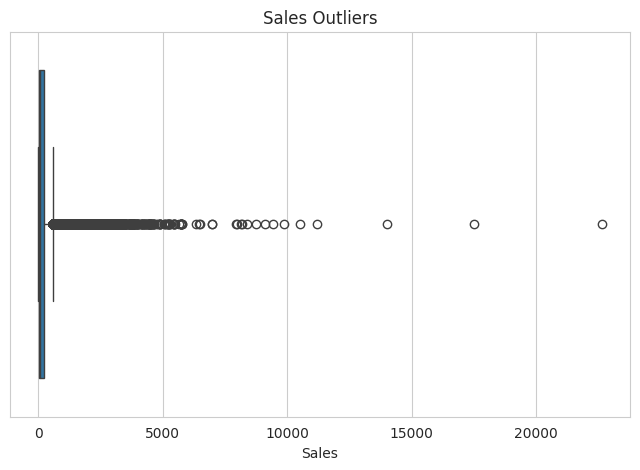

In [13]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["Sales"])

plt.title("Sales Outliers")

save_plot("01_Sales_Outliers.png")

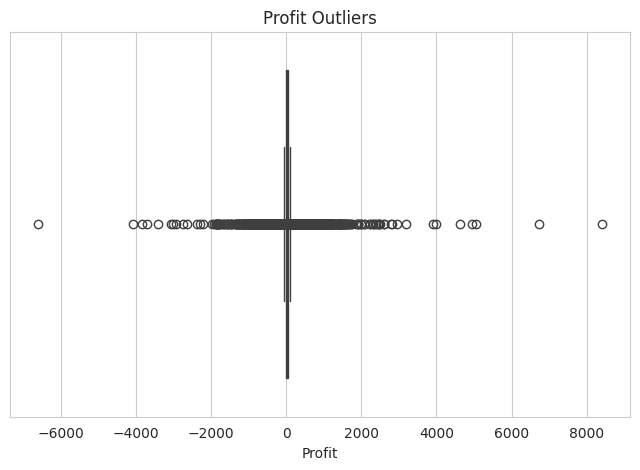

In [14]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["Profit"])

plt.title("Profit Outliers")

save_plot("02_Profit_Outliers.png")

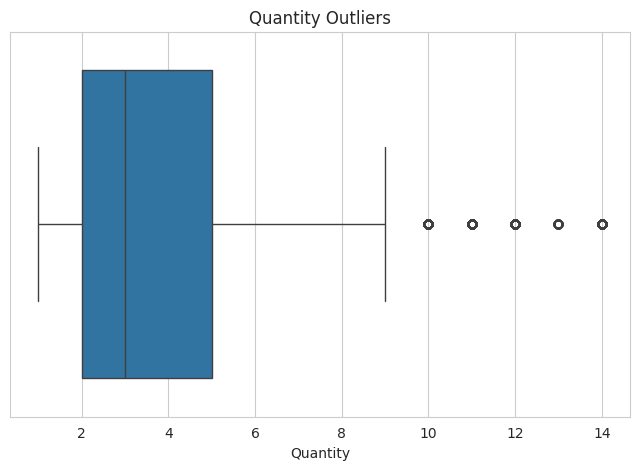

In [15]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["Quantity"])

plt.title("Quantity Outliers")

save_plot("03_Quantity_Outliers.png")

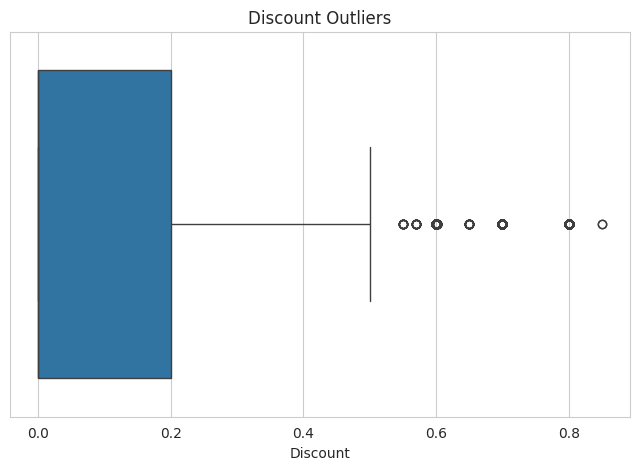

In [16]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["Discount"])

plt.title("Discount Outliers")

save_plot("04_Discount_Outliers.png")

In [17]:
cols = ["Sales","Profit","Quantity","Discount"]

for col in cols:

    Q1 = df[col].quantile(0.25)

    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5*IQR

    upper = Q3 + 1.5*IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]

print(df.shape)

(33806, 24)


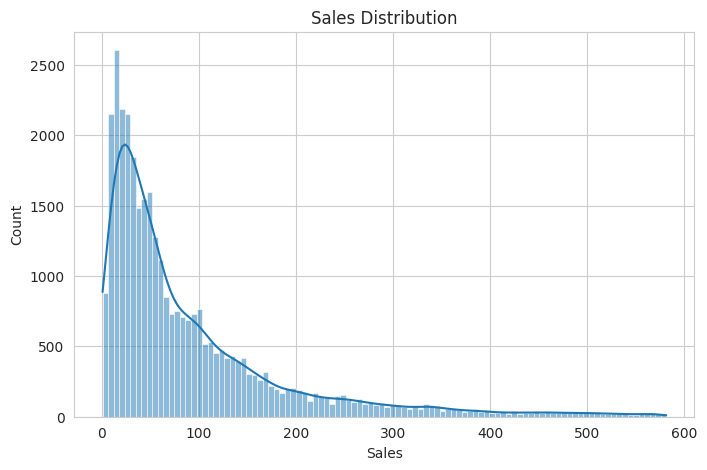

In [18]:
plt.figure(figsize=(8,5))

sns.histplot(df["Sales"], kde=True)

plt.title("Sales Distribution")

save_plot("05_Sales_Distribution.png")

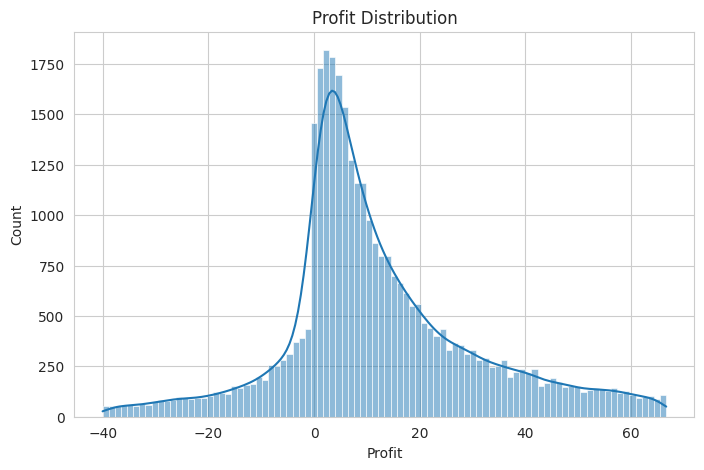

In [19]:
plt.figure(figsize=(8,5))

sns.histplot(df["Profit"], kde=True)

plt.title("Profit Distribution")

save_plot("06_Profit_Distribution.png")

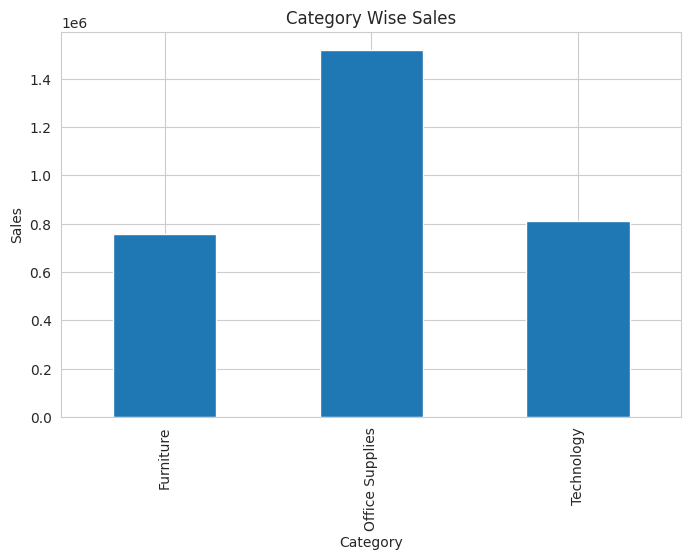

In [20]:
plt.figure(figsize=(8,5))

category_sales = df.groupby("Category")["Sales"].sum()

category_sales.plot(kind="bar")

plt.title("Category Wise Sales")

plt.ylabel("Sales")

save_plot("07_Category_Sales.png")

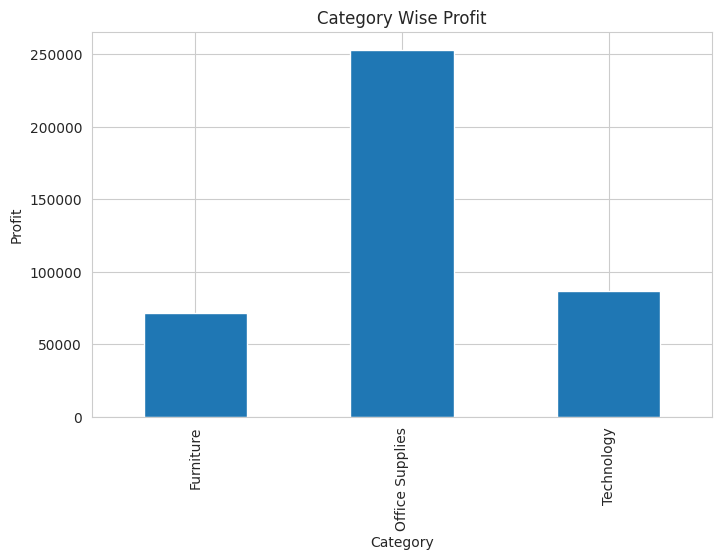

In [21]:
plt.figure(figsize=(8,5))

category_profit = df.groupby("Category")["Profit"].sum()

category_profit.plot(kind="bar")

plt.title("Category Wise Profit")

plt.ylabel("Profit")

save_plot("08_Category_Profit.png")

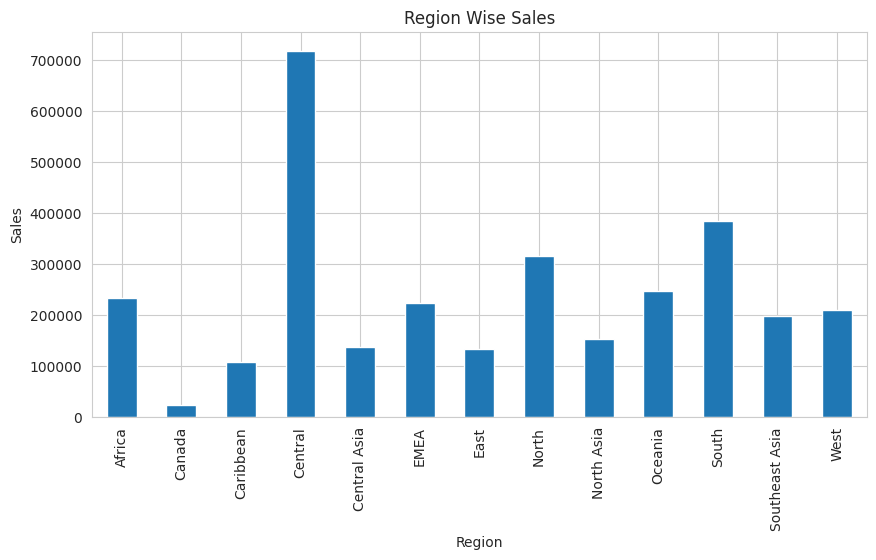

In [22]:
plt.figure(figsize=(10,5))

region_sales = df.groupby("Region")["Sales"].sum()

region_sales.plot(kind="bar")

plt.title("Region Wise Sales")

plt.ylabel("Sales")

save_plot("09_Region_Sales.png")

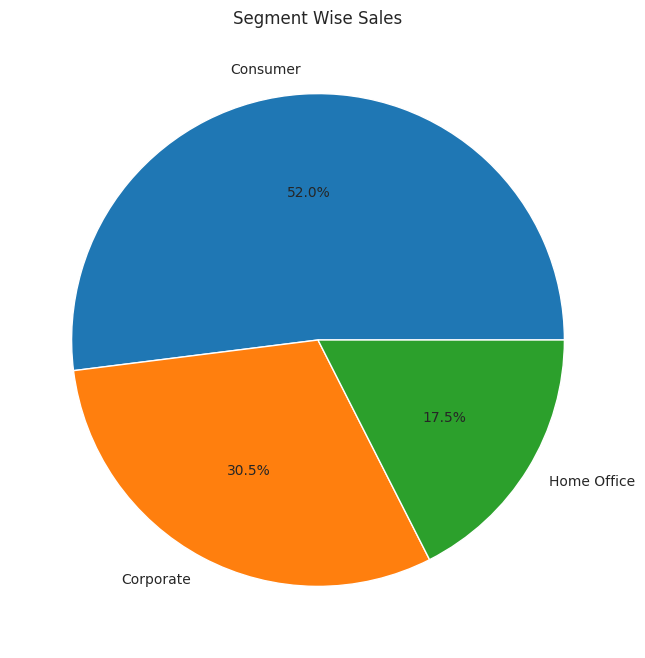

In [23]:
plt.figure(figsize=(8,8))

segment_sales = df.groupby("Segment")["Sales"].sum()

plt.pie(
    segment_sales,
    labels=segment_sales.index,
    autopct="%1.1f%%"
)

plt.title("Segment Wise Sales")

save_plot("10_Segment_Sales.png")

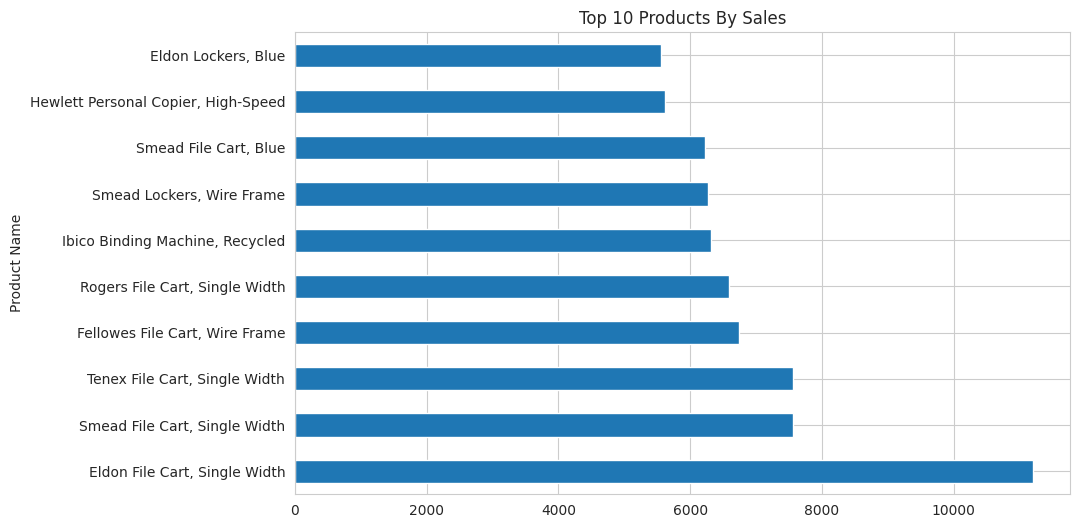

In [24]:
top_products = (
    df.groupby("Product Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

top_products.plot(kind="barh")

plt.title("Top 10 Products By Sales")

save_plot("11_Top_Products.png")

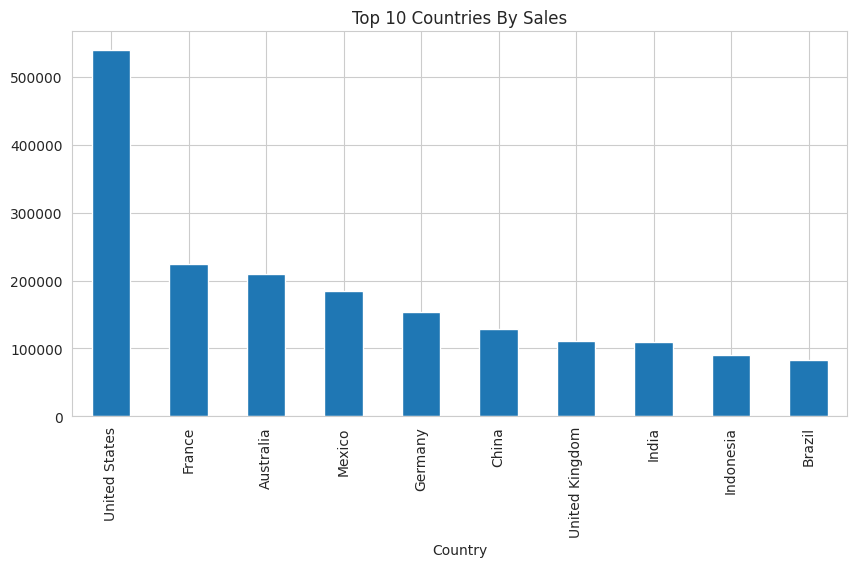

In [25]:
top_country = (
    df.groupby("Country")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))

top_country.plot(kind="bar")

plt.title("Top 10 Countries By Sales")

save_plot("12_Top_Countries.png")

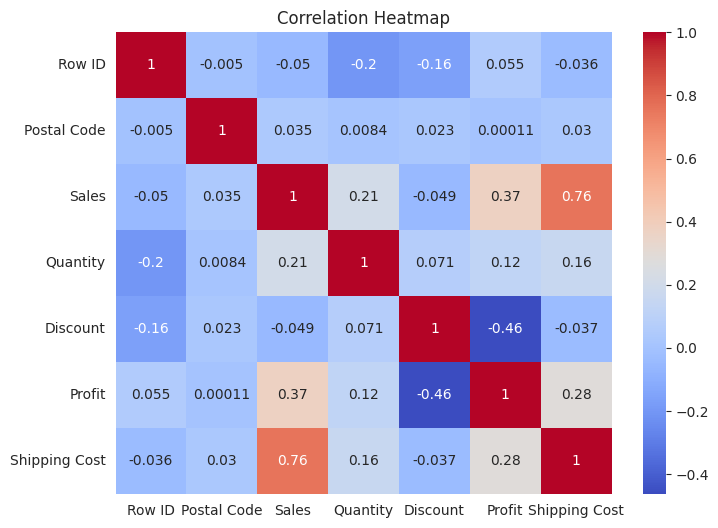

In [26]:
plt.figure(figsize=(8,6))

numeric_df = df.select_dtypes(include=np.number)

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

save_plot("13_Correlation_Heatmap.png")

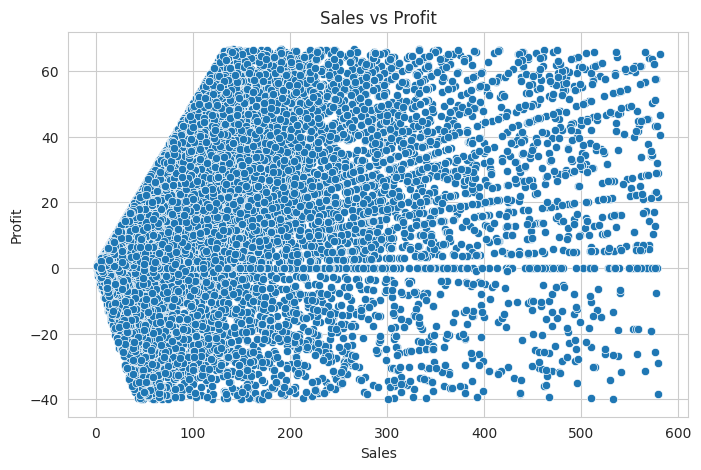

In [27]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="Sales",
    y="Profit",
    data=df
)

plt.title("Sales vs Profit")

save_plot("14_Sales_vs_Profit.png")

/tmp/ipykernel_58/425666461.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["Order Date"] = pd.to_datetime(df["Order Date"])


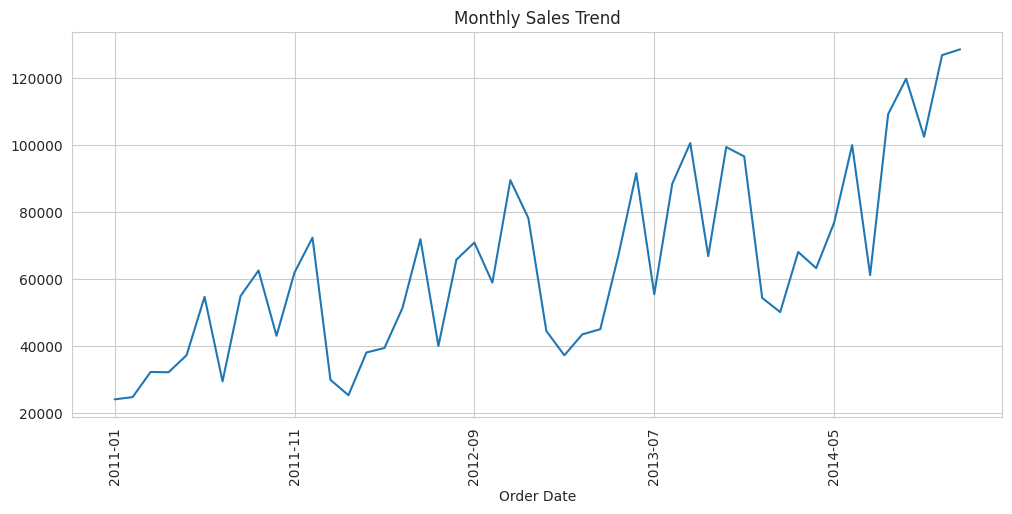

In [28]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

monthly_sales = df.groupby(
    df["Order Date"].dt.to_period("M")
)["Sales"].sum()

monthly_sales.index = monthly_sales.index.astype(str)

plt.figure(figsize=(12,5))

monthly_sales.plot()

plt.title("Monthly Sales Trend")

plt.xticks(rotation=90)

save_plot("15_Monthly_Sales_Trend.png")

In [29]:
print("Total Sales:",
      round(df["Sales"].sum(),2))

print("Total Profit:",
      round(df["Profit"].sum(),2))

print("Best Category:",
      df.groupby("Category")["Sales"].sum().idxmax())

print("Best Region:",
      df.groupby("Region")["Sales"].sum().idxmax())

print("Best Segment:",
      df.groupby("Segment")["Sales"].sum().idxmax())

Total Sales: 3088807.94
Total Profit: 411388.57
Best Category: Office Supplies
Best Region: Central
Best Segment: Consumer


In [30]:
df.to_csv(
    "/kaggle/working/Cleaned_Global_Superstore.csv",
    index=False
)

print("Cleaned dataset saved.")

Cleaned dataset saved.


In [31]:
shutil.make_archive(
    "/kaggle/working/Global_Superstore_Visual_Reports",
    "zip",
    "/kaggle/working/Visual_Reports"
)

print("ZIP File Created Successfully")

ZIP File Created Successfully
